In [3]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, auc, accuracy_score,  classification_report, precision_recall_curve, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score, train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn import metrics
from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE

In [ ]:
# df_sissi = pd.DataFrame(pd.read_excel("C:/bla/Waste/MA/Data/SISSIz_Data_di_Excel/sissi.xlsx"))
# df_sissiz_mono = pd.DataFrame(pd.read_excel("C:/bla/Waste/MA/Data/SISSIz_Data_di_Excel/sissiz_mono.xlsx"))
# df_sissiz_di = pd.DataFrame(pd.read_excel("C:/bla/Waste/MA/Data/SISSIz_Data_di_Excel/sissiz_di.xlsx"))
# df_multiperm_mono = pd.DataFrame(pd.read_excel("C:/bla/Waste/MA/Data/SISSIz_Data_di_Excel/multiperm_mono.xlsx"))
# df_multiperm_di = pd.DataFrame(pd.read_excel("C:/bla/Waste/MA/Data/SISSIz_Data_di_Excel/multiperm_di.xlsx"))
# df_aln_shuffle = pd.DataFrame(pd.read_excel("C:/bla/Waste/MA/Data/SISSIz_Data_di_Excel/alifoldz.xlsx"))

In [ ]:
# df_sissi = pd.DataFrame(pd.read_excel("D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/sissi.xlsx"))
# df_sissiz_mono = pd.DataFrame(pd.read_excel('D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/sissiz_mono.xlsx'))
# df_sissiz_di = pd.DataFrame(pd.read_excel('D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/sissiz_di.xlsx'))
# df_sissiz_mono = pd.DataFrame(pd.read_excel('D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/multiperm_mono.xlsx'))
# df_multiperm_di = pd.DataFrame(pd.read_excel('D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/multiperm_di.xlsx'))
# df_aln_shuffle = pd.DataFrame(pd.read_excel('D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/alifoldz.xlsx'))

In [4]:
# Datei-Pfade
file_names = {
    'sissi': 'D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/sissi.xlsx',
    'sissiz_mono': 'D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/sissiz_mono.xlsx',
    'sissiz_di': 'D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/sissiz_di.xlsx',
    'multiperm_mono': 'D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/multiperm_mono.xlsx',
    'multiperm_di': 'D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/multiperm_di.xlsx',
    'aln-shuffle': 'D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/alifoldz.xlsx'
}

# Leerer DataFrame für die Daten
df = pd.DataFrame()

# Excel-Dateien laden
for name, file_path in file_names.items():
    try:
        df[name] = pd.read_excel(file_path)['z-score calculated from 7. 8. and 9.']
    except Exception as e:
        print(f"Fehler beim Laden von {name}: {e}")

print(df.head(10))

   sissi  sissiz_mono  sissiz_di  multiperm_mono  multiperm_di  aln-shuffle
0 -17.54         0.65       0.12           -5.48         -3.87       -15.64
1 -33.39         1.23       1.30           -7.34         -7.06       -11.03
2 -28.15         0.00       0.23           -5.99         -5.05        -9.90
3 -21.36         0.03       1.60           -9.41         -4.71       -11.28
4 -21.70         1.69       0.85           -7.75         -5.14       -10.88
5 -21.97        -0.42      -0.67           -4.46         -6.88        -5.73
6 -25.27         1.55      -1.16           -4.92         -3.29       -13.23
7 -25.11        -0.17       0.80           -3.11         -3.66       -10.24
8 -24.12         1.23      -1.44           -5.47         -6.58       -12.34
9 -27.28         0.03       1.15           -6.47         -9.81        -9.47


In [ ]:
sum_sissi = df["sissi"].astype(float).describe().to_frame()
sum_sissiz_mono = df["sissiz_mono"].astype(float).describe().to_frame()
sum_sissiz_di = df["sissiz_di"].astype(float).describe().to_frame()
sum_multiperm_mono = df["multiperm_mono"].astype(float).describe().to_frame()
sum_multiperm_di = df["multiperm_di"].astype(float).describe().to_frame()
sum_aln_shuffle = df["aln-shuffle"].astype(float).describe().to_frame()

summary = pd.concat([sum_sissi, sum_sissiz_mono, sum_multiperm_mono, sum_multiperm_di, sum_aln_shuffle], axis=1)
summary.columns = ["sum_sissi", "sum_sissiz_mono", "sum_multiperm_mono", "sum_multiperm_di", "sum_aln_shuffle"]

print(summary)

NameError: name 'df' is not defined

In [ ]:
def plot_roc_curve(fper, tper, y):
    plt.plot(fper, tper, color='red', label='ROC')
    plt.plot([0, 1], [0, 1], color='green', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(y)
    plt.legend()

In [ ]:
def plot_confusion_matrix(x, z):
    group_names = ['True Neg','False Pos','False Neg','True Pos']

    group_counts = ["{0:0.0f}".format(value) for value in
                x.flatten()]

    group_percentages = ["{0:.2%}".format(value) for value in
                     x.flatten()/np.sum(x)]

    labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in
          zip(group_names,group_counts,group_percentages)]

    labels = np.asarray(labels).reshape(2,2)

    ax = sns.heatmap(x, annot=labels, fmt='', cmap='Blues')

    ax.set_title(z)
    ax.set_xlabel('\nPredicted Values')
    ax.set_ylabel('Actual Values ')

    ## Ticket labels - List must be in alphabetical order
    ax.xaxis.set_ticklabels(['False','True'])
    ax.yaxis.set_ticklabels(['False','True'])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df[["sissi"]], df[["multiperm_mono"]], test_size=0.3, random_state=0)
print("X_train: " + str(X_train.shape))
print("y_train: " + str(y_train.shape))
print("X_test: " + str(X_test.shape))
print("y_test: " + str(y_test.shape))

# Reshape der Eingabevariablen
X_train = X_train.values.reshape(-1, 1)
X_test = X_test.values.reshape(-1, 1)

# Logistische Regression durchführen
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Vorhersagen auf dem Testdatensatz machen
y_pred = model.predict(X_test)

In [ ]:
def receiverOperationCharacteristics(x, y, z):
    # Beispiel-Daten
    positive_file = x.astype(float)  # Positive Control Set
    negative_file = y.astype(float)  # Negative Control Set

    # Labels für positive und negative Daten erstellen
    positive_labels = np.ones(len(positive_file))
    negative_labels = np.zeros(len(negative_file))

    # Daten und Labels zusammenführen
    data = np.concatenate([positive_file, negative_file], axis=0)
    labels = np.concatenate([positive_labels, negative_labels])

    # ROC-Kurve berechnen
    fpr, tpr, thresholds = roc_curve(labels, data)

    # AUC berechnen
    auc_score = auc(fpr, tpr)

    # ROC-Kurve plotten
    plt.plot(fpr, tpr, label='ROC curve (AUC = %0.2f)' % auc_score)
    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(z)
    plt.legend(loc="upper left")
    plt.show()

In [ ]:
positive_file = df[["sissi"]]
negative_file = df[["multiperm_mono"]]
title = "SISSI Mulitperm_mono"
receiverOperationCharacteristics(positive_file, negative_file, title)

In [ ]:
# threshold = -3
# df["multiperm_mono_binary"] = (df["multiperm_mono"] > threshold).astype(int)

# # Trainings- und Testdatensatz aufteilen
# X_train, X_test, y_train, y_test = train_test_split(df[["sissi"]], df["multiperm_mono_binary"], test_size=0.3, random_state=42)

# # Logistische Regression
# model = LogisticRegression(max_iter=1000)
# model.fit(X_train, y_train)

# # Wahrscheinlichkeiten für Klasse 1
# y_scores = model.predict_proba(X_test)[:, 1]


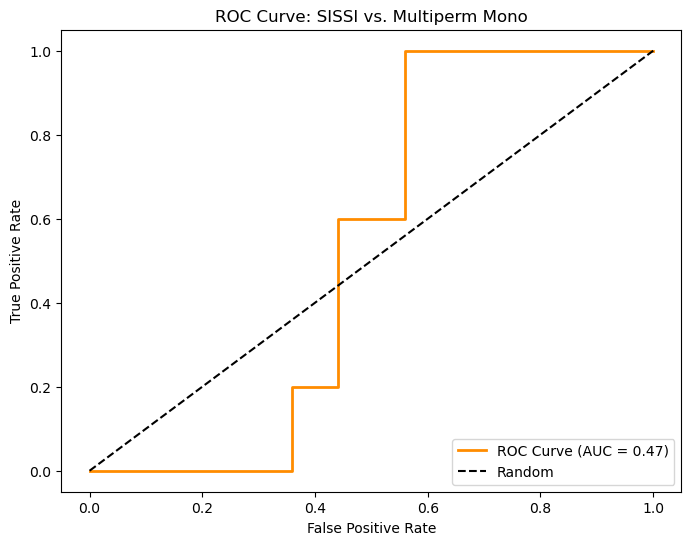

AUC: 0.47


In [ ]:
# # ROC-Kurve berechnen
# fpr, tpr, thresholds = roc_curve(y_test, y_scores)
# auc_score = auc(tpr, fpr)

# # ROC-Kurve plotten
# plt.figure(figsize=(8, 6))
# plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.2f})', color='darkorange', lw=2)
# plt.plot([0, 1], [0, 1], 'k--', label='Random')  # Diagonale
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('ROC Curve: SISSI vs. Multiperm Mono')
# plt.legend(loc="lower right")
# plt.show()

# print(f"AUC: {auc_score:.2f}")